# 系統初始化

## 環境設定與套件匯入

In [59]:
#做跟「電腦作業系統」有關的事情（搬移檔案、砍資料夾、讀取環境變數）時，就必須先寫 import os，把(作業系統的工具箱)取用。
import os

# 定義要安裝的套件清單
packages = "pandas numpy scipy scikit-learn imbalanced-learn matplotlib seaborn"

# 執行安裝指令
os.system(f"pip install {packages}")

0

## CSV欄位及資料整理

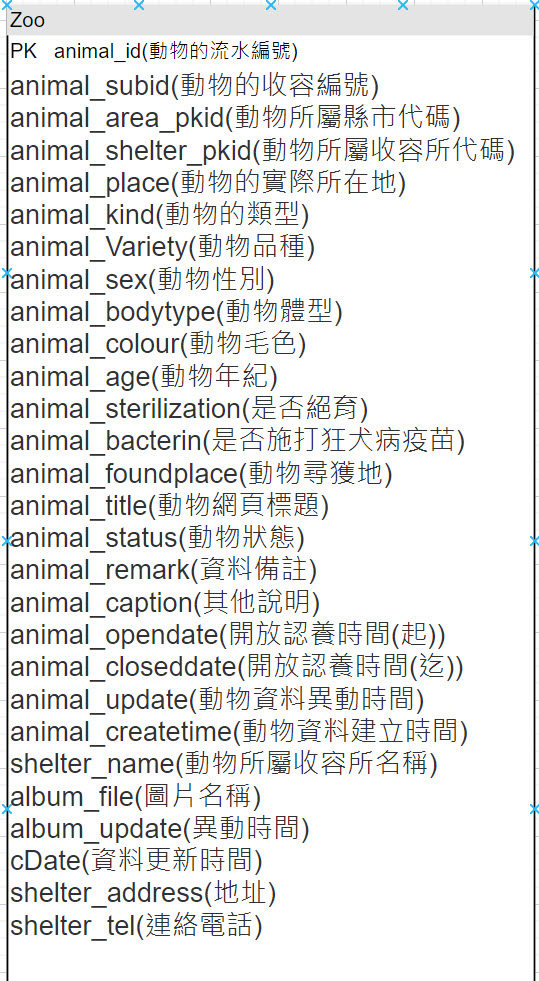

CSV格式整理

1.原欄位修改原則 "x_前二碼" _前第一碼+_+_後第一二碼

2.新增欄位原則  "x_前二碼_xx" 後二碼流水號


欄位資料處理原則 V:x;Y:參考;N不處理 共7575筆

1.a_id:動物的流水編號->(N) PK 唯一值 流水碼

2.a_su:動物的收容編號->(N) PK 唯一值前三碼縣巿碼第四五碼收容所碼

3.a_ar動物所屬縣市代碼->(N) 共24個地區

**4.a_sh動物所屬收容所代碼->(V) 共33個收容所;其中63;96;81 名稱不一致(需先校正**)

5.a_pl動物的實際所在地->(N)(校正後不處理) 同a_sh

**6.a_ki動物的類型->(V) 狗;貓;其他(9)筆去除**

7.a_va動物品種->(V->N) 內容太雜亂先踢除

**8.a_se動物性別->(V) F;M;N(71)筆 N隨機**

**9.a_bo動物體型->(V) 大中小**

**10.a_co動物毛色->(V)** 26筆空白隨機

**11.a_ag動物年紀->(V)** 成人;小孩 23空白筆隨機

**12.a_st是否絕育->(V) F;N;T**

13.a_ba是否施打狂犬病疫苗->(N) 一定要

14.a_fo動物尋獲地->(N) 太雜

15.a_ti動物網頁標題->(N) 全空值

16.a_sa動物狀態->(N) 全OPEN

17.a_re資料備註->(V->N) 太雜

18.a_ca其他說明->(N) 全空值

**19.a_op開放認養時間(起)->(V) DATE-a_op 產生新欄位上架距今天數###**

20.a_cl開放認養時間(迄)->(N) 全一致

21.a_up動物資料異動時間->(N) 853筆空值

22.a_cr動物資料建立時間->(N) 無意義

23.s_na動物所屬收容所名稱->(N) 同a_sh

24.a_fi圖片名稱->(N) 儲存圖片網址(1002)筆空值

25.b_up圖片異動時間->(N) 全空值

26.cDa資料更新時間->(N) 1150筆空值

27.地址->(N) 同a_sh

28.聯絡電話->(N) 同a_sh


zoo_d2.csv

1.處理動物類型 其他去除

2.校正收容所誤植資料

zoo_d3.csv

1.去除欄位都空值欄位 a_ti ; a_ca ; b_up

2.a_op 開放日期空值被誤判"1900/1/1", 重新眾數取值

新增收容所 table she (33)筆資料

CREATE TABLE she AS
SELECT DISTINCT a_ar, a_sh, a_pl, s_na, s_ad, S_te
FROM zoo_d3
ORDER BY a_sh;


建立二個 VIEW

CREATE TABLE dotcat_she AS
SELECT * FROM dotcatsu LEFT JOIN she ON dotcatsu.country_code=she.a_ars ;

CREATE TABLE zoo_she AS
SELECT * FROM zoo_d3 LEFT JOIN she ON zoo_d3.a_ar = she.a_ars;

## import 需要的套件

In [60]:
import pandas as pd           #pandas
import numpy as np            #numpy
import matplotlib.pyplot as plt     #繪圖套件
import matplotlib.font_manager as fm   #繪圖字型
import warnings
warnings.filterwarnings('ignore') #出現一些非錯誤的「警告」隱藏警告，讓輸出的畫面保持乾淨，專注於結果。

pd.set_option('display.max_columns', None) #當表格欄位很多時，Pandas 預設會隱藏中間的欄位（顯示為 ...）。設定為 None 代表強制顯示所有欄位。
pd.set_option('display.width', 120)  #設定輸出畫面的寬度為 120 個字元，防止表格在換行時跑版。

# 中文字型設定（讓 matplotlib 顯示中文）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'PingFang TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False # Matplotlib 預設會使用 Unicode 的減號（−），這在某些字型下會顯示成方塊。將其設為 False 會改用標準的連字號（-），確保負數數值能正常顯示。

## 載入資料(Colab 雲端資料)


In [61]:
from google.colab import drive
#import pandas as pd
drive.mount('/content/gdrive') # 此處需要登入google帳號
# 獲取授權碼之後輸入即可連動雲端硬碟

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 讀取資料

In [62]:
 df=pd.read_csv('//content/gdrive/MyDrive/謝大哥/zoo_d3.csv',header=0)
df.head()
#雲端 Colab的讀取方式

,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te
0,451258,AAADG1150503001,3,50,新北市板橋區公立動物之家,貓,混種貓,M,SMALL,虎斑色,ADULT,T,F,OPEN,NaN,2999/12/31,2026/5/3,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158
1,451109,AAAHG1150430001,3,58,新北市五股區公立動物之家,狗,混種犬,M,MEDIUM,灰白色,ADULT,F,F,OPEN,NaN,2999/12/31,2026/4/30,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265
2,450754,AAADG1150428001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,M,SMALL,咖啡色,ADULT,F,F,OPEN,NaN,2999/12/31,2026/4/28,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158
3,450445,AAADG1150425001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,F,SMALL,黑色,ADULT,F,F,OPEN,NaN,2999/12/31,2026/4/25,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158
4,450429,AAAHG1150425001,3,58,新北市五股區公立動物之家,狗,哈士奇(西伯利亞雪橇犬),M,BIG,灰白色,ADULT,T,F,OPEN,NaN,2999/12/31,2026/4/25,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265


*其他連線讀取方式*
從Google雲端硬碟

from google.colab import files
uploaded=files.upload()

FILE = '機器學習資料前處理_教學資料集.csv'
df = pd.read_csv(FILE, parse_dates=['入職日期'])

# 觀察資料
• 檢視前幾筆 → df.head()

• 檢視欄位與型態 → df.info()

• 檢視整體統計 → df.describe()

★ 第一步永遠是「先看一眼」

・count 那一列若小於總筆數 → 該欄位有空值

・min / max 是否合理？(例如月薪 -45000 顯然有問題)(年紀不可能200)

Label觀察資料分佈與異常值

數值觀察統計資料

空值都要被處理

In [63]:
print('資料維度：', df.shape)
print('（7566 筆資料的橫斷面快照，含 20 個欄位）')
df.head()

資料維度： (7566, 20)
（7566 筆資料的橫斷面快照，含 20 個欄位）


,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te
0,451258,AAADG1150503001,3,50,新北市板橋區公立動物之家,貓,混種貓,M,SMALL,虎斑色,ADULT,T,F,OPEN,NaN,2999/12/31,2026/5/3,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158
1,451109,AAAHG1150430001,3,58,新北市五股區公立動物之家,狗,混種犬,M,MEDIUM,灰白色,ADULT,F,F,OPEN,NaN,2999/12/31,2026/4/30,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265
2,450754,AAADG1150428001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,M,SMALL,咖啡色,ADULT,F,F,OPEN,NaN,2999/12/31,2026/4/28,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158
3,450445,AAADG1150425001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,F,SMALL,黑色,ADULT,F,F,OPEN,NaN,2999/12/31,2026/4/25,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158
4,450429,AAAHG1150425001,3,58,新北市五股區公立動物之家,狗,哈士奇(西伯利亞雪橇犬),M,BIG,灰白色,ADULT,T,F,OPEN,NaN,2999/12/31,2026/4/25,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7566 entries, 0 to 7565
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   a_id    7566 non-null   int64 
 1   a_su    7566 non-null   object
 2   a_ar    7566 non-null   int64 
 3   a_sh    7566 non-null   int64 
 4   a_pl    7566 non-null   object
 5   a_ki    7566 non-null   object
 6   a_va    7561 non-null   object
 7   a_se    7566 non-null   object
 8   a_bo    7566 non-null   object
 9   a_co    7390 non-null   object
 10  a_ag    7216 non-null   object
 11  a_st    7566 non-null   object
 12  a_ba    7566 non-null   object
 13  a_sa    7566 non-null   object
 14  a_op    7277 non-null   object
 15  a_cl    7566 non-null   object
 16  a_cr    7566 non-null   object
 17  s_na    7566 non-null   object
 18  s_ad    7566 non-null   object
 19  s_te    7566 non-null   object
dtypes: int64(3), object(17)
memory usage: 1.2+ MB


In [65]:
df.describe(include='all')

,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te
count,7566.000000,7566,7566.000000,7566.000000,7566,7566,7561,7566,7566,7390,7216,7566,7566,7566,7277,7566,7566,7566,7566,7566
unique,NaN,7560,NaN,NaN,33,2,64,3,3,29,2,3,1,1,1921,1,2201,33,36,35
top,NaN,AAADG1150302001,NaN,NaN,臺北市動物之家,狗,混種犬,M,MEDIUM,黑色,ADULT,T,F,OPEN,2021/4/11,2999/12/31,2025/9/23,臺北市動物之家,臺北市內湖區安美街191號,02-87913254
freq,NaN,2,NaN,NaN,960,5732,5303,3810,4516,2915,5406,4372,7566,7566,111,7566,65,960,960,960
mean,334143.446603,NaN,8.887391,66.001586,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,135150.111996,NaN,6.704371,13.361425,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,26311.000000,NaN,2.000000,48.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,268444.500000,NaN,3.000000,53.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,402211.500000,NaN,6.000000,62.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,437591.750000,NaN,16.000000,76.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [66]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
a_id,7566.0,NaN,NaN,NaN,334143.446603,135150.111996,26311.0,268444.5,402211.5,437591.75,451275.0
a_su,7566,7560,AAADG1150302001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_ar,7566.0,NaN,NaN,NaN,8.887391,6.704371,2.0,3.0,6.0,16.0,23.0
a_sh,7566.0,NaN,NaN,NaN,66.001586,13.361425,48.0,53.0,62.0,76.0,96.0
a_pl,7566,33,臺北市動物之家,960,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_ki,7566,2,狗,5732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_va,7561,64,混種犬,5303,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_se,7566,3,M,3810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_bo,7566,3,MEDIUM,4516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
a_co,7390,29,黑色,2915,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 空值偵測與處理

In [67]:
report = pd.DataFrame({
    '空值數': df.isna().sum(),
    '空值比例(%)': (df.isna().mean() * 100).round(2)
})
report[report['空值數'] > 0]

,空值數,空值比例(%)
a_va,5,0.07
a_co,176,2.33
a_ag,350,4.63
a_op,289,3.82


In [68]:
# (1) 名目尺度：眾數補
df['a_va'] = df['a_va'].fillna(df['a_va'].mode()[0])  # df = df.dropna(subset=['性別'])只要「性別」欄位有缺，就刪除該列
df['a_co'] = df['a_co'].fillna(df['a_co'].mode()[0])
df['a_ag'] = df['a_ag'].fillna(df['a_ag'].mode()[0])
df['a_op'] = df['a_op'].fillna(df['a_op'].mode()[0])

import numpy as np
# 1. 找出所有值為 'N' 的位置（建立布林遮罩）
mask = df['a_se'] == 'N'
# 2. 計算總共有幾筆 'N'
n_missing = mask.sum()
# 3. 只有在有 'N' 的時候才執行替換，避免程式出錯
if n_missing > 0:
    # 隨機產生與 'N' 的數量相同、由 'F' 和 'M' 組成的陣列
    random_choices = np.random.choice(['F', 'M'], size=n_missing)

    # 將這些隨機值填回原本為 'N' 的位置
    df.loc[mask, 'a_se'] = random_choices

# 1. 找出所有值為 'N' 的位置（建立布林遮罩）
mask = df['a_st'] == 'N'
# 2. 計算總共有幾筆 'N'
n_missing = mask.sum()
# 3. 只有在有 'N' 的時候才執行替換，避免程式出錯
if n_missing > 0:
    # 隨機產生與 'N' 的數量相同、由 'F' 和 'T' 組成的陣列
    random_choices = np.random.choice(['F', 'T'], size=n_missing)

    # 將這些隨機值填回原本為 'N' 的位置
    df.loc[mask, 'a_st'] = random_choices

#隨機方法
#df['a_co'] = df['a_co'].apply(lambda x: np.random.choice(df['a_co'].dropna()) if pd.isna(x) else x)

# 取得今天的日期
today = pd.Timestamp.today().normalize()

# 將 'a_op' 欄位轉換為日期時間格式
df['a_op'] = pd.to_datetime(df['a_op'], errors='coerce')

# 計算相差天數，並用 .dt.days 轉為純數字
df['a_stay'] = (today - df['a_op']).dt.days

print('✅ 所有x的空值都已補完')
df.to_csv('zoo_alld.csv')
df.isna().sum()
#df.head()

✅ 所有x的空值都已補完


,0
a_id,0
a_su,0
a_ar,0
a_sh,0
a_pl,0
a_ki,0
a_va,0
a_se,0
a_bo,0
a_co,0


#離群值偵測（IQR 法）

**IQR 公式**：
- 四分位距 IQR = Q3 − Q1
- 下界 = Q1 − 1.5 × IQR
- 上界 = Q3 + 1.5 × IQR
- 超出上下界 → 視為離群值

In [69]:
def find_outliers_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])  # quantile()計算「分位數」
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return s[(s < low) | (s > high)], (low, high)

for col in ['a_stay']:
    out, (low, high) = find_outliers_iqr(df[col].dropna())
    print(f'{col}: {len(out):3d} 個離群值，'  f'合理範圍 [{low:.1f}, {high:.1f}]')



a_stay:  28 個離群值，合理範圍 [-1993.6, 3749.4]


In [70]:
df=df[df["a_stay"]< 3655 ]

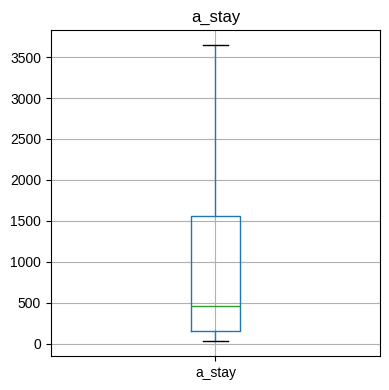

In [71]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 🔥 終極修正：直接使用 Colab 內建 100% 存在的字型，免下載安裝
plt.rcParams['font.family'] = 'Liberation Sans'
plt.rcParams['axes.unicode_minus'] = False
# 視覺化：箱型圖
fig, axes = plt.subplots(1, 1, figsize=(4, 4))  # axes[0] 是第一張圖 ； plt.subplots(1, 3) 1 列與 3 欄，寬度為 13，高度為 4
for i, col in enumerate(['a_stay']):
    df.boxplot(column=col, ax=axes)    # df.boxplot(column=col)：叫 Pandas 針對 col 欄位畫出箱型圖。
    axes.set_title(col)
plt.tight_layout()  # plt.tight_layout()：這行非常重要，它會自動調整子圖之間的間距，防止標題或座標軸標籤重疊在一起，讓畫面變整齊。
plt.show()          # plt.show()：正式將圖表執行在螢幕上。

# 處理類別不平衡（SMOTE）

**現況**：是否離職 = 90 : 10  
**問題**：模型若全部猜「不離職」就有 90% 準確率，毫無意義。

**常見解法**：
- Undersampling 欠抽樣  RandomUnderSampler
- Oversampling 過抽樣   SMOTE
- Proportional ：等比例抽樣   RandomUnderSampler
> ⚠ **SMOTE 必須在 train_test_split 之後做，且只針對訓練集**，避免資料外洩。

In [72]:
from sklearn.model_selection import train_test_split



# 類別變數編碼

In [73]:
# 🔥 核心修正：從 sklearn 載入 OneHotEncoder 工具
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop=None, sparse_output=False)
arr = ohe.fit_transform(df[['a_pl', 'a_ki', 'a_se', 'a_bo', 'a_co', 'a_ag']])
cols = ohe.get_feature_names_out(['a_pl', 'a_ki', 'a_se', 'a_bo', 'a_co', 'a_ag'])
# 2. 轉換為 DataFrame，並確保索引(Index)與原資料一致
df_ohe = pd.DataFrame(arr, columns=cols, index=df.index).astype(int)

# 3. 直接合併：不執行 .drop()，直接 join
# 這樣原始的 '性別' 與 '部門' 都會留在資料表的最左邊
df = df.join(df_ohe)

# 查看結果
df.to_csv('zoo_allLd.csv')
print(df)

        a_id             a_su  a_ar  a_sh           a_pl a_ki                  a_va a_se    a_bo a_co   a_ag a_st  \
0     451258  AAADG1150503001     3    50   新北市板橋區公立動物之家    貓  混種貓                     M   SMALL  虎斑色  ADULT    T   
1     451109  AAAHG1150430001     3    58   新北市五股區公立動物之家    狗         混種犬              M  MEDIUM  灰白色  ADULT    F   
2     450754  AAADG1150428001     3    50   新北市板橋區公立動物之家    狗           貴賓犬            M   SMALL  咖啡色  ADULT    F   
3     450445  AAADG1150425001     3    50   新北市板橋區公立動物之家    狗           貴賓犬            F   SMALL   黑色  ADULT    F   
4     450429  AAAHG1150425001     3    58   新北市五股區公立動物之家    狗          哈士奇(西伯利亞雪橇犬)    M     BIG  灰白色  ADULT    T   
...      ...              ...   ...   ...            ...  ...                   ...  ...     ...  ...    ...  ...   
7561  181155  EAAAG1091021011     9    96    苗栗縣動物保護教育園區    狗         混種犬              F  MEDIUM   黃色  ADULT    F   
7562  265268        111071405     2    49        臺北市動物之家    狗   

#  數值標準化




In [74]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
df_encoded=df
# 比例尺度欄位（含可標準化的等距尺度）
num_cols = ['a_stay']
X = df_encoded.drop(columns=['a_sh', 'a_ki', 'a_se', 'a_bo', 'a_co', 'a_ag'])
y = df_encoded['a_stay']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_mm28 = X_train.copy()
X_test_mm28  = X_test.copy()

scaler_mm28 = MinMaxScaler(feature_range=(0.2, 0.8))
X_train_mm28[num_cols] = scaler_mm28.fit_transform(X_train[num_cols])
X_test_mm28[num_cols]  = scaler_mm28.transform(X_test[num_cols])

print('\n【方法三：區間縮放 0.2–0.8】')
print('訓練集：min=0.2, max=0.8')
print(X_train_mm28[num_cols].describe().round(3))
print('\n測試集（同樣以訓練集為基準，可能落在 0.2–0.8 之外）')
print(X_test_mm28[num_cols].describe().round(3))


【方法三：區間縮放 0.2–0.8】
訓練集：min=0.2, max=0.8
         a_stay
count  6021.000
mean      0.342
std       0.151
min       0.200
25%       0.221
50%       0.269
75%       0.447
max       0.800

測試集（同樣以訓練集為基準，可能落在 0.2–0.8 之外）
         a_stay
count  1506.000
mean      0.351
std       0.156
min       0.201
25%       0.225
50%       0.281
75%       0.472
max       0.800


# 常態分配檢驗

In [75]:
from scipy import stats

# 重新載入原始資料（含新欄位）
df_raw =df

# (1) 偏度與峰度
print('=== 偏度 / 峰度 ===')
for col in ['a_stay']:
    sk = df[col].skew()
    ku = df[col].kurt()
    flag = '⚠ 偏態嚴重' if abs(sk) > 1 else ''
    print(f'{col:6s}: 偏度skew = {sk:6.2f}, 峰度kurt = {ku:6.2f}  {flag}')

=== 偏度 / 峰度 ===
a_stay: 偏度skew =   1.07, 峰度kurt =   0.10  ⚠ 偏態嚴重


# 對數修正


In [76]:
import numpy as np

# 三種轉換比較（針對加班時數）
df_raw['log_a_stay']  = np.log1p(df_raw['a_stay'])      # log1p = ln(1 + x)
df_raw['sqrt_a_stay'] = np.sqrt(df_raw['a_stay'])         # ② 平方根
df_raw['inv_a_stay']  = 1 / (df_raw['a_stay'] + 1)        # ③ 倒數

# 比較 skewness（越接近 0 越好）
print('=== a_stay三種轉換比較 ===')
for c in ['a_stay', 'log_a_stay', 'sqrt_a_stay', 'inv_a_stay']:
    print(f'{c:18s}: skew = {df_raw[c].skew():7.3f}')  #{c:18s} 18: 代表佔用 18 個字元的寬度。s: 代表字串（String）。

=== a_stay三種轉換比較 ===
a_stay            : skew =   1.072
log_a_stay        : skew =  -0.196
sqrt_a_stay       : skew =   0.493
inv_a_stay        : skew =   1.831


In [77]:
!wget -O taipei_sans_tc_beta.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download
!mv taipei_sans_tc_beta.ttf /usr/local/lib/python3.12/dist-packages/matplotlib//mpl-data/fonts/ttf

from matplotlib.font_manager import FontProperties


# 自定義字體變數
myfont = FontProperties(fname=r'/usr/local/lib/python3.12/dist-packages/matplotlib/mpl-data/fonts/ttf/taipei_sans_tc_beta.ttf')



--2026-06-08 03:00:04--  https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.google.com (drive.google.com)... 108.177.11.138, 108.177.11.100, 108.177.11.139, ...
Connecting to drive.google.com (drive.google.com)|108.177.11.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_ [following]
--2026-06-08 03:00:04--  https://drive.usercontent.google.com/download?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.11.132, 2607:f8b0:400c:c01::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.11.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20659344 (20M) [application/octet-stream]
Saving to: ‘taipei_sans_tc_beta.ttf’

taipei_sans_tc_beta 100%[===================>]  19.70M  --.-KB/s    in 0.09s   

2026-06-08 03:00:05 (2

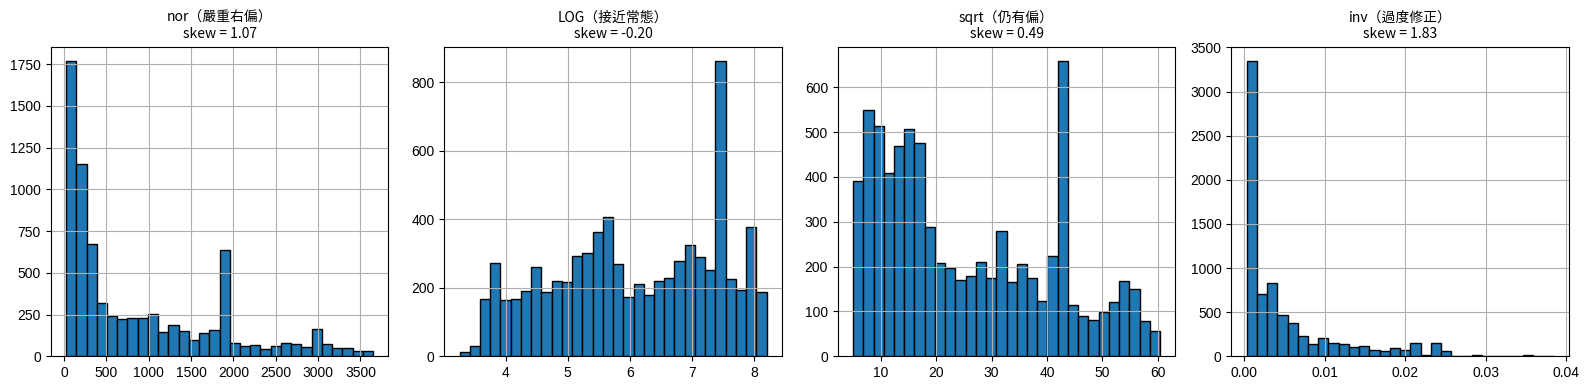

In [78]:


fig, axes = plt.subplots(1, 4, figsize=(16, 4))
cols = ['a_stay', 'log_a_stay', 'sqrt_a_stay', 'inv_a_stay']
titles = ['nor（嚴重右偏）', 'LOG（接近常態）', 'sqrt（仍有偏）', 'inv（過度修正）']
for i, (c, t) in enumerate(zip(cols, titles)):
    df_raw[c].hist(ax=axes[i], bins=30, edgecolor='black')
    axes[i].set_title(f'{t}\nskew = {df_raw[c].skew():.2f}', fontproperties=myfont)
plt.tight_layout()
plt.show()

In [79]:
# 下載指令：輸出 CSV + Excel
OUT_CSV  = '機器學習資料前處理_教學資料集_清洗完成.csv'  #  OUT_XLSX = '機器學習資料前處理_教學資料集_清洗完成.xlsx'
df_raw.to_csv(OUT_CSV,  index=False, encoding='utf-8-sig')    # final.to_excel(OUT_XLSX, index=False, sheet_name='清洗完成')  下載 Excel

print(f'✅ 清洗完成資料集 shape: {df_raw.shape}')
print(f'   原始 14 欄 → 最終 {df_raw.shape[1]} 欄（已完成 OneHotEncoder + Ordinal 編碼）')
print()
print(f'📦 已匯出格式（請從檔案總管下載）：')
print(f'   {OUT_CSV}')            # OUT_XLSX = '機器學習資料前處理_教學資料集_清洗完成.xlsx'

df_raw.head(3)

✅ 清洗完成資料集 shape: (7527, 95)
   原始 14 欄 → 最終 95 欄（已完成 OneHotEncoder + Ordinal 編碼）

📦 已匯出格式（請從檔案總管下載）：
   機器學習資料前處理_教學資料集_清洗完成.csv


,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te,a_stay,a_pl_南投縣公立動物收容所,a_pl_嘉義市動物保護教育園區,a_pl_嘉義縣動物保護教育園區,a_pl_基隆市寵物銀行,a_pl_宜蘭縣流浪動物中途之家,a_pl_屏東縣公立犬貓中途之家,a_pl_彰化縣流浪狗中途之家,a_pl_新北市三芝區公立動物之家,a_pl_新北市中和區公立動物之家,a_pl_新北市五股區公立動物之家,a_pl_新北市八里區公立動物之家,a_pl_新北市政府動物保護防疫處,a_pl_新北市新店區公立動物之家,a_pl_新北市板橋區公立動物之家,a_pl_新北市淡水區公立動物之家,a_pl_新北市瑞芳區公立動物之家,a_pl_新竹市動物保護教育園區,a_pl_新竹縣動物保護教育園區,a_pl_桃園市動物保護教育園區,a_pl_澎湖縣流浪動物收容中心,a_pl_臺中市動物之家南屯園區,a_pl_臺中市動物之家后里園區,a_pl_臺北市動物之家,a_pl_臺南市動物之家善化站,a_pl_臺南市動物之家灣裡站,a_pl_臺東縣動物收容中心,a_pl_花蓮縣狗貓躍動園區,a_pl_苗栗縣動物保護教育園區,a_pl_連江縣動物之家,a_pl_金門縣動物收容中心,a_pl_雲林縣流浪動物收容所,a_pl_高雄市壽山動物保護教育園區,a_pl_高雄市燕巢動物保護關愛園區,a_ki_狗,a_ki_貓,a_se_F,a_se_M,a_bo_BIG,a_bo_MEDIUM,a_bo_SMALL,a_co_三花色,a_co_咖啡棕色,a_co_咖啡白色,a_co_咖啡色,a_co_咖啡黑色,a_co_棕灰色,a_co_棕白色,a_co_棕色,a_co_棕黑色,a_co_灰白色,a_co_灰色,a_co_灰黑色,a_co_玳瑁色,a_co_白色,a_co_米色,a_co_花白色,a_co_花色,a_co_虎斑白色,a_co_虎斑色,a_co_黃白色,a_co_黃色,a_co_黃虎斑色,a_co_黃黑色,a_co_黑棕色,a_co_黑灰色,a_co_黑白色,a_co_黑色,a_co_黑虎斑色,a_co_黑黃色,a_ag_ADULT,a_ag_CHILD,log_a_stay,sqrt_a_stay,inv_a_stay
0,451258,AAADG1150503001,3,50,新北市板橋區公立動物之家,貓,混種貓,M,SMALL,虎斑色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/5/3,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
1,451109,AAAHG1150430001,3,58,新北市五股區公立動物之家,狗,混種犬,M,MEDIUM,灰白色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/30,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,1884,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
2,450754,AAADG1150428001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,M,SMALL,咖啡色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/28,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531


# 熱力圖

In [80]:
from google.colab import drive
import pandas as pd
import numpy as np
import folium

# 1. 挂載 Google 雲端硬碟並讀取資料
drive.mount('/content/gdrive')
df = pd.read_csv('/content/gdrive/MyDrive/謝大哥/zoo_d3.csv', header=0)

# 2. 統計每個收容所的現存動物數量
shelter_counts = df['a_pl'].value_counts().to_dict()

# 3. 建立台灣各主要收容所的實際經緯度座標字典
shelter_coords = {
    "基隆市寵物銀行":[25.1275, 121.6754], "臺北市動物之家": [25.0607, 121.6034],
    "新北市政府動物保護防疫處":[25.0041, 121.4604], "新北市板橋區公立動物之家": [24.9956, 121.4479],
    "新北市中和區公立動物之家": [24.9759, 121.4887], "新北市五股區公立動物之家": [25.0779, 121.4158],
    "新北市八里區公立動物之家": [25.0879, 121.3983], "新北市淡水區公立動物之家": [25.2103, 121.4304],
    "新北市三芝區公立動物之家": [25.2267, 121.5377], "新北市新店區公立動物之家": [24.9294, 121.4895],
    "新北市瑞芳區公立動物之家": [25.0763, 121.7995], "桃園市動物保護教育園區": [25.0086, 121.0278],
    "新竹市動物保護教育園區": [24.8333, 120.9197], "新竹縣動物保護教育園區": [24.8285, 121.0151],
    "苗栗縣動物保護教育園區": [24.4997, 120.7941], "臺中市動物之家南屯園區": [24.1513, 120.5761],
    "臺中市動物之家后里園區": [24.2867, 120.7097], "彰化縣流浪狗中途之家": [23.9695, 120.6197],
    "南投縣公立動物收容所": [23.9061, 120.6699], "雲林縣流浪動物收容所": [23.6984, 120.5261],
    "嘉義市動物保護教育園區": [23.4644, 120.4688], "嘉義縣動物保護教育園區": [23.5478, 120.5055],
    "臺南市動物之家灣裡站": [22.9369, 120.1942], "臺南市動物之家善化站": [23.1490, 120.3317],
    "高雄市壽山動物保護教育園區": [22.6372, 120.2781], "高雄市燕巢動物保護關愛園區": [22.7929, 120.4046],
    "屏東縣公立犬貓中途之家": [22.6581, 120.5485], "宜蘭縣流浪動物中途之家": [24.6674, 121.8316],
    "花蓮縣狗貓躍動園區": [23.8062, 121.4981], "臺東縣動物收容中心": [22.7229, 121.1004],
    "澎湖縣流浪動物收容中心": [23.5524, 119.6273], "金門縣動物收容中心": [24.4443, 118.4447],
    "連江縣動物之家": [26.1665, 119.9605]
}

# 4. 初始化地圖（一次到位：聚焦台灣全島，並載入各種底圖）
m = folium.Map(location=[23.7, 121.0], zoom_start=7.5)

# 加入大標題 HTML
title_html = '''
    <h1 align="center" style="font-size:36px; font-weight:bold; margin-top: 15px; margin-bottom: 10px; width: 100%;">
        <b>各收容所容納流浪動物統計</b>
    </h1>
'''
m.get_root().html.add_child(folium.Element(title_html))

# 設定圖層切換選項
folium.TileLayer('OpenStreetMap', name='標準街道圖').add_to(m)
folium.TileLayer('cartodbpositron', name='淺色底圖').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri',
    name='Esri 衛星圖'
).add_to(m)

# 5. 計算收容數量的最大與最小值，用來做圓圈半徑與顏色的縮放基準
all_counts = [count for name, count in shelter_counts.items() if name in shelter_coords]
if all_counts:
    max_animals = max(all_counts)
    min_animals = min(all_counts)
else:
    max_animals, min_animals = 1000, 1

def get_radius(count):
    """根據收容數量動態調整圓圈大小 (範圍設定在 8 到 35 像素)"""
    if max_animals == min_animals:
        return 15
    return 8 + (count - min_animals) / (max_animals - min_animals) * 27

def get_color(count):
    """根據數量調整顏色 (藍色代表量少安全，橘紅代表收容數量較多)"""
    ratio = (count - min_animals) / (max_animals - min_animals) if max_animals != min_animals else 0.5
    if ratio < 0.2:
        return '#1f77b4' # 藍色
    elif ratio < 0.5:
        return '#2ca02c' # 綠色
    elif ratio < 0.8:
        return '#ff7f0e' # 橘色
    else:
        return '#d62728' # 紅色

# 6. 開始繪製收容所標記 (CircleMarker)
for shelter_name, count in shelter_counts.items():
    if shelter_name in shelter_coords:
        coord = shelter_coords[shelter_name]
        radius = get_radius(count)
        color = get_color(count)

        popup_text = f"<b>{shelter_name}</b><br>目前收容動物數量: <b>{count}</b> 隻"

        folium.CircleMarker(
            location=coord,
            radius=radius,
            popup=folium.Popup(popup_text, max_width=250),
            tooltip=f"{shelter_name}: {count} 隻",
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            weight=1.5
        ).add_to(m)

# 7. 加上圖層控制面板 (這行一定要放在所有圖層與標記都加完之後！)
folium.LayerControl().add_to(m)

# 8. 儲存資料與地圖
df.to_csv("zoo_f4.csv", index=False)
m.save("taiwan_shelter_map.html")
print("收容所分佈地圖已成功生成並儲存為 'taiwan_shelter_map.html'！")

# 9. 顯示地圖
m

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
收容所分佈地圖已成功生成並儲存為 'taiwan_shelter_map.html'！


In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io

In [82]:
diabetes = pd.read_csv('機器學習資料前處理_教學資料集_清洗完成.csv', header=0)
diabetes.head()

,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te,a_stay,a_pl_南投縣公立動物收容所,a_pl_嘉義市動物保護教育園區,a_pl_嘉義縣動物保護教育園區,a_pl_基隆市寵物銀行,a_pl_宜蘭縣流浪動物中途之家,a_pl_屏東縣公立犬貓中途之家,a_pl_彰化縣流浪狗中途之家,a_pl_新北市三芝區公立動物之家,a_pl_新北市中和區公立動物之家,a_pl_新北市五股區公立動物之家,a_pl_新北市八里區公立動物之家,a_pl_新北市政府動物保護防疫處,a_pl_新北市新店區公立動物之家,a_pl_新北市板橋區公立動物之家,a_pl_新北市淡水區公立動物之家,a_pl_新北市瑞芳區公立動物之家,a_pl_新竹市動物保護教育園區,a_pl_新竹縣動物保護教育園區,a_pl_桃園市動物保護教育園區,a_pl_澎湖縣流浪動物收容中心,a_pl_臺中市動物之家南屯園區,a_pl_臺中市動物之家后里園區,a_pl_臺北市動物之家,a_pl_臺南市動物之家善化站,a_pl_臺南市動物之家灣裡站,a_pl_臺東縣動物收容中心,a_pl_花蓮縣狗貓躍動園區,a_pl_苗栗縣動物保護教育園區,a_pl_連江縣動物之家,a_pl_金門縣動物收容中心,a_pl_雲林縣流浪動物收容所,a_pl_高雄市壽山動物保護教育園區,a_pl_高雄市燕巢動物保護關愛園區,a_ki_狗,a_ki_貓,a_se_F,a_se_M,a_bo_BIG,a_bo_MEDIUM,a_bo_SMALL,a_co_三花色,a_co_咖啡棕色,a_co_咖啡白色,a_co_咖啡色,a_co_咖啡黑色,a_co_棕灰色,a_co_棕白色,a_co_棕色,a_co_棕黑色,a_co_灰白色,a_co_灰色,a_co_灰黑色,a_co_玳瑁色,a_co_白色,a_co_米色,a_co_花白色,a_co_花色,a_co_虎斑白色,a_co_虎斑色,a_co_黃白色,a_co_黃色,a_co_黃虎斑色,a_co_黃黑色,a_co_黑棕色,a_co_黑灰色,a_co_黑白色,a_co_黑色,a_co_黑虎斑色,a_co_黑黃色,a_ag_ADULT,a_ag_CHILD,log_a_stay,sqrt_a_stay,inv_a_stay
0,451258,AAADG1150503001,3,50,新北市板橋區公立動物之家,貓,混種貓,M,SMALL,虎斑色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/5/3,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
1,451109,AAAHG1150430001,3,58,新北市五股區公立動物之家,狗,混種犬,M,MEDIUM,灰白色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/30,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,1884,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
2,450754,AAADG1150428001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,M,SMALL,咖啡色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/28,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
3,450445,AAADG1150425001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,F,SMALL,黑色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/25,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,7.541683,43.405069,0.000531
4,450429,AAAHG1150425001,3,58,新北市五股區公立動物之家,狗,哈士奇(西伯利亞雪橇犬),M,BIG,灰白色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/4/25,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,1884,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531


In [83]:
diabetes.columns

Index(['a_id', 'a_su', 'a_ar', 'a_sh', 'a_pl', 'a_ki', 'a_va', 'a_se', 'a_bo', 'a_co', 'a_ag', 'a_st', 'a_ba', 'a_sa',
       'a_op', 'a_cl', 'a_cr', 's_na', 's_ad', 's_te', 'a_stay', 'a_pl_南投縣公立動物收容所', 'a_pl_嘉義市動物保護教育園區',
       'a_pl_嘉義縣動物保護教育園區', 'a_pl_基隆市寵物銀行', 'a_pl_宜蘭縣流浪動物中途之家', 'a_pl_屏東縣公立犬貓中途之家', 'a_pl_彰化縣流浪狗中途之家',
       'a_pl_新北市三芝區公立動物之家', 'a_pl_新北市中和區公立動物之家', 'a_pl_新北市五股區公立動物之家', 'a_pl_新北市八里區公立動物之家', 'a_pl_新北市政府動物保護防疫處',
       'a_pl_新北市新店區公立動物之家', 'a_pl_新北市板橋區公立動物之家', 'a_pl_新北市淡水區公立動物之家', 'a_pl_新北市瑞芳區公立動物之家', 'a_pl_新竹市動物保護教育園區',
       'a_pl_新竹縣動物保護教育園區', 'a_pl_桃園市動物保護教育園區', 'a_pl_澎湖縣流浪動物收容中心', 'a_pl_臺中市動物之家南屯園區', 'a_pl_臺中市動物之家后里園區',
       'a_pl_臺北市動物之家', 'a_pl_臺南市動物之家善化站', 'a_pl_臺南市動物之家灣裡站', 'a_pl_臺東縣動物收容中心', 'a_pl_花蓮縣狗貓躍動園區', 'a_pl_苗栗縣動物保護教育園區',
       'a_pl_連江縣動物之家', 'a_pl_金門縣動物收容中心', 'a_pl_雲林縣流浪動物收容所', 'a_pl_高雄市壽山動物保護教育園區', 'a_pl_高雄市燕巢動物保護關愛園區', 'a_ki_狗',
       'a_ki_貓', 'a_se_F', 'a_se_M', 'a_bo_BIG', 'a_bo_MEDIUM', 'a_bo_SMALL', 'a_co_三花色', 'a_co_咖啡棕色', 'a_co_咖啡白色'

In [84]:
diabetes.head()

,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te,a_stay,a_pl_南投縣公立動物收容所,a_pl_嘉義市動物保護教育園區,a_pl_嘉義縣動物保護教育園區,a_pl_基隆市寵物銀行,a_pl_宜蘭縣流浪動物中途之家,a_pl_屏東縣公立犬貓中途之家,a_pl_彰化縣流浪狗中途之家,a_pl_新北市三芝區公立動物之家,a_pl_新北市中和區公立動物之家,a_pl_新北市五股區公立動物之家,a_pl_新北市八里區公立動物之家,a_pl_新北市政府動物保護防疫處,a_pl_新北市新店區公立動物之家,a_pl_新北市板橋區公立動物之家,a_pl_新北市淡水區公立動物之家,a_pl_新北市瑞芳區公立動物之家,a_pl_新竹市動物保護教育園區,a_pl_新竹縣動物保護教育園區,a_pl_桃園市動物保護教育園區,a_pl_澎湖縣流浪動物收容中心,a_pl_臺中市動物之家南屯園區,a_pl_臺中市動物之家后里園區,a_pl_臺北市動物之家,a_pl_臺南市動物之家善化站,a_pl_臺南市動物之家灣裡站,a_pl_臺東縣動物收容中心,a_pl_花蓮縣狗貓躍動園區,a_pl_苗栗縣動物保護教育園區,a_pl_連江縣動物之家,a_pl_金門縣動物收容中心,a_pl_雲林縣流浪動物收容所,a_pl_高雄市壽山動物保護教育園區,a_pl_高雄市燕巢動物保護關愛園區,a_ki_狗,a_ki_貓,a_se_F,a_se_M,a_bo_BIG,a_bo_MEDIUM,a_bo_SMALL,a_co_三花色,a_co_咖啡棕色,a_co_咖啡白色,a_co_咖啡色,a_co_咖啡黑色,a_co_棕灰色,a_co_棕白色,a_co_棕色,a_co_棕黑色,a_co_灰白色,a_co_灰色,a_co_灰黑色,a_co_玳瑁色,a_co_白色,a_co_米色,a_co_花白色,a_co_花色,a_co_虎斑白色,a_co_虎斑色,a_co_黃白色,a_co_黃色,a_co_黃虎斑色,a_co_黃黑色,a_co_黑棕色,a_co_黑灰色,a_co_黑白色,a_co_黑色,a_co_黑虎斑色,a_co_黑黃色,a_ag_ADULT,a_ag_CHILD,log_a_stay,sqrt_a_stay,inv_a_stay
0,451258,AAADG1150503001,3,50,新北市板橋區公立動物之家,貓,混種貓,M,SMALL,虎斑色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/5/3,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
1,451109,AAAHG1150430001,3,58,新北市五股區公立動物之家,狗,混種犬,M,MEDIUM,灰白色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/30,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,1884,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
2,450754,AAADG1150428001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,M,SMALL,咖啡色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/28,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531
3,450445,AAADG1150425001,3,50,新北市板橋區公立動物之家,狗,貴賓犬,F,SMALL,黑色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/25,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,1884,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,7.541683,43.405069,0.000531
4,450429,AAAHG1150425001,3,58,新北市五股區公立動物之家,狗,哈士奇(西伯利亞雪橇犬),M,BIG,灰白色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/4/25,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,1884,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,7.541683,43.405069,0.000531


In [85]:
len(diabetes)

7527

In [86]:
zoo_to_norm = ['a_id',  'a_ar', 'a_sh', 'a_stay', 'a_pl_南投縣公立動物收容所', 'a_pl_嘉義市動物保護教育園區',
       'a_pl_嘉義縣動物保護教育園區', 'a_pl_基隆市寵物銀行', 'a_pl_宜蘭縣流浪動物中途之家', 'a_pl_屏東縣公立犬貓中途之家', 'a_pl_彰化縣流浪狗中途之家',
       'a_pl_新北市三芝區公立動物之家', 'a_pl_新北市中和區公立動物之家', 'a_pl_新北市五股區公立動物之家', 'a_pl_新北市八里區公立動物之家', 'a_pl_新北市政府動物保護防疫處',
       'a_pl_新北市新店區公立動物之家', 'a_pl_新北市板橋區公立動物之家', 'a_pl_新北市淡水區公立動物之家', 'a_pl_新北市瑞芳區公立動物之家', 'a_pl_新竹市動物保護教育園區',
       'a_pl_新竹縣動物保護教育園區', 'a_pl_桃園市動物保護教育園區', 'a_pl_澎湖縣流浪動物收容中心', 'a_pl_臺中市動物之家南屯園區', 'a_pl_臺中市動物之家后里園區',
       'a_pl_臺北市動物之家', 'a_pl_臺南市動物之家善化站', 'a_pl_臺南市動物之家灣裡站', 'a_pl_臺東縣動物收容中心', 'a_pl_花蓮縣狗貓躍動園區', 'a_pl_苗栗縣動物保護教育園區',
       'a_pl_連江縣動物之家', 'a_pl_金門縣動物收容中心', 'a_pl_雲林縣流浪動物收容所', 'a_pl_高雄市壽山動物保護教育園區', 'a_pl_高雄市燕巢動物保護關愛園區', 'a_ki_狗',
       'a_ki_貓', 'a_se_F', 'a_se_M', 'a_bo_BIG', 'a_bo_MEDIUM', 'a_bo_SMALL', 'a_co_三花色', 'a_co_咖啡棕色', 'a_co_咖啡白色',
       'a_co_咖啡色', 'a_co_咖啡黑色', 'a_co_棕灰色', 'a_co_棕白色', 'a_co_棕色', 'a_co_棕黑色', 'a_co_灰白色', 'a_co_灰色', 'a_co_灰黑色',
       'a_co_玳瑁色', 'a_co_白色', 'a_co_米色', 'a_co_花白色', 'a_co_花色', 'a_co_虎斑白色', 'a_co_虎斑色', 'a_co_黃白色', 'a_co_黃色',
       'a_co_黃虎斑色', 'a_co_黃黑色', 'a_co_黑棕色', 'a_co_黑灰色', 'a_co_黑白色', 'a_co_黑色', 'a_co_黑虎斑色', 'a_co_黑黃色', 'a_ag_ADULT',
       'a_ag_CHILD', 'log_a_stay', 'sqrt_a_stay', 'inv_a_stay']

In [87]:
# 正規化公式: x' = (x - min) / (max - min) * 0.6 + 0.2 → 映射到 [0.2, 0.8]
diabetes[zoo_to_norm] = diabetes[zoo_to_norm].apply(
    lambda x: (x - x.min()) / (x.max() - x.min()) * 0.6 + 0.2)
diabetes.head()

,a_id,a_su,a_ar,a_sh,a_pl,a_ki,a_va,a_se,a_bo,a_co,a_ag,a_st,a_ba,a_sa,a_op,a_cl,a_cr,s_na,s_ad,s_te,a_stay,a_pl_南投縣公立動物收容所,a_pl_嘉義市動物保護教育園區,a_pl_嘉義縣動物保護教育園區,a_pl_基隆市寵物銀行,a_pl_宜蘭縣流浪動物中途之家,a_pl_屏東縣公立犬貓中途之家,a_pl_彰化縣流浪狗中途之家,a_pl_新北市三芝區公立動物之家,a_pl_新北市中和區公立動物之家,a_pl_新北市五股區公立動物之家,a_pl_新北市八里區公立動物之家,a_pl_新北市政府動物保護防疫處,a_pl_新北市新店區公立動物之家,a_pl_新北市板橋區公立動物之家,a_pl_新北市淡水區公立動物之家,a_pl_新北市瑞芳區公立動物之家,a_pl_新竹市動物保護教育園區,a_pl_新竹縣動物保護教育園區,a_pl_桃園市動物保護教育園區,a_pl_澎湖縣流浪動物收容中心,a_pl_臺中市動物之家南屯園區,a_pl_臺中市動物之家后里園區,a_pl_臺北市動物之家,a_pl_臺南市動物之家善化站,a_pl_臺南市動物之家灣裡站,a_pl_臺東縣動物收容中心,a_pl_花蓮縣狗貓躍動園區,a_pl_苗栗縣動物保護教育園區,a_pl_連江縣動物之家,a_pl_金門縣動物收容中心,a_pl_雲林縣流浪動物收容所,a_pl_高雄市壽山動物保護教育園區,a_pl_高雄市燕巢動物保護關愛園區,a_ki_狗,a_ki_貓,a_se_F,a_se_M,a_bo_BIG,a_bo_MEDIUM,a_bo_SMALL,a_co_三花色,a_co_咖啡棕色,a_co_咖啡白色,a_co_咖啡色,a_co_咖啡黑色,a_co_棕灰色,a_co_棕白色,a_co_棕色,a_co_棕黑色,a_co_灰白色,a_co_灰色,a_co_灰黑色,a_co_玳瑁色,a_co_白色,a_co_米色,a_co_花白色,a_co_花色,a_co_虎斑白色,a_co_虎斑色,a_co_黃白色,a_co_黃色,a_co_黃虎斑色,a_co_黃黑色,a_co_黑棕色,a_co_黑灰色,a_co_黑白色,a_co_黑色,a_co_黑虎斑色,a_co_黑黃色,a_ag_ADULT,a_ag_CHILD,log_a_stay,sqrt_a_stay,inv_a_stay
0,0.799976,AAADG1150503001,0.228571,0.225,新北市板橋區公立動物之家,貓,混種貓,M,SMALL,虎斑色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/5/3,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,0.507866,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.719841,0.615949,0.204029
1,0.799766,AAAHG1150430001,0.228571,0.325,新北市五股區公立動物之家,狗,混種犬,M,MEDIUM,灰白色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/30,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,0.507866,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.719841,0.615949,0.204029
2,0.799264,AAADG1150428001,0.228571,0.225,新北市板橋區公立動物之家,狗,貴賓犬,M,SMALL,咖啡色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/28,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,0.507866,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.719841,0.615949,0.204029
3,0.798828,AAADG1150425001,0.228571,0.225,新北市板橋區公立動物之家,狗,貴賓犬,F,SMALL,黑色,ADULT,F,F,OPEN,2021-04-11,2999/12/31,2026/4/25,新北市板橋區公立動物之家,新北市板橋區板城路28-1號,02-89662158,0.507866,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.719841,0.615949,0.204029
4,0.798806,AAAHG1150425001,0.228571,0.325,新北市五股區公立動物之家,狗,哈士奇(西伯利亞雪橇犬),M,BIG,灰白色,ADULT,T,F,OPEN,2021-04-11,2999/12/31,2026/4/25,新北市五股區公立動物之家,新北市五股區外寮路9-9號,02-82925265,0.507866,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.719841,0.615949,0.204029


In [88]:
y    = diabetes['log_a_stay']
diabetes = diabetes.drop(['a_id', 'a_su', 'a_ar', 'a_sh', 'a_pl', 'a_ki', 'a_va', 'a_se', 'a_bo', 'a_co',
                          'a_ag', 'a_st', 'a_ba', 'a_sa', 'a_op', 'a_cl', 'a_cr', 's_na', 's_ad', 's_te','a_stay','sqrt_a_stay','inv_a_stay','log_a_stay'], axis=1)
diabetes.head(10)

,a_pl_南投縣公立動物收容所,a_pl_嘉義市動物保護教育園區,a_pl_嘉義縣動物保護教育園區,a_pl_基隆市寵物銀行,a_pl_宜蘭縣流浪動物中途之家,a_pl_屏東縣公立犬貓中途之家,a_pl_彰化縣流浪狗中途之家,a_pl_新北市三芝區公立動物之家,a_pl_新北市中和區公立動物之家,a_pl_新北市五股區公立動物之家,a_pl_新北市八里區公立動物之家,a_pl_新北市政府動物保護防疫處,a_pl_新北市新店區公立動物之家,a_pl_新北市板橋區公立動物之家,a_pl_新北市淡水區公立動物之家,a_pl_新北市瑞芳區公立動物之家,a_pl_新竹市動物保護教育園區,a_pl_新竹縣動物保護教育園區,a_pl_桃園市動物保護教育園區,a_pl_澎湖縣流浪動物收容中心,a_pl_臺中市動物之家南屯園區,a_pl_臺中市動物之家后里園區,a_pl_臺北市動物之家,a_pl_臺南市動物之家善化站,a_pl_臺南市動物之家灣裡站,a_pl_臺東縣動物收容中心,a_pl_花蓮縣狗貓躍動園區,a_pl_苗栗縣動物保護教育園區,a_pl_連江縣動物之家,a_pl_金門縣動物收容中心,a_pl_雲林縣流浪動物收容所,a_pl_高雄市壽山動物保護教育園區,a_pl_高雄市燕巢動物保護關愛園區,a_ki_狗,a_ki_貓,a_se_F,a_se_M,a_bo_BIG,a_bo_MEDIUM,a_bo_SMALL,a_co_三花色,a_co_咖啡棕色,a_co_咖啡白色,a_co_咖啡色,a_co_咖啡黑色,a_co_棕灰色,a_co_棕白色,a_co_棕色,a_co_棕黑色,a_co_灰白色,a_co_灰色,a_co_灰黑色,a_co_玳瑁色,a_co_白色,a_co_米色,a_co_花白色,a_co_花色,a_co_虎斑白色,a_co_虎斑色,a_co_黃白色,a_co_黃色,a_co_黃虎斑色,a_co_黃黑色,a_co_黑棕色,a_co_黑灰色,a_co_黑白色,a_co_黑色,a_co_黑虎斑色,a_co_黑黃色,a_ag_ADULT,a_ag_CHILD
0,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
1,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
3,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2
4,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
5,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
6,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2
7,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2
9,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.8,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.8,0.2


In [89]:
from sklearn.model_selection import train_test_split
# train_test_split 參數說明：
#   test_size    : 測試集比例
#   random_state : 亂數種子，固定值可使結果可重現
X_train, X_test, y_train, y_test = train_test_split(
    np.asanyarray(diabetes), np.asanyarray(y),
    test_size=0.33, random_state=101)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (5043, 71) Test: (2484, 71)


In [90]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================================
# 對應簡報第 44 頁「預測的準確性 - 整體考量」
# -----------------------------------------------------------------------------
#   R² (決定係數)            = 1 - Σ(y_i - ŷ_i)² / Σ(y_i - ȳ)²
#   Adjusted R²              = 1 - (1-R²)(n-1)/(n-p-1)
#   MAE (Mean Absolute Error) = (1/N) Σ|ŷ_i - y_i|
#   RMSE (Root Mean Square Error) = sqrt((1/N) Σ(ŷ_i - y_i)²)
#   RAE (Relative Absolute Error) = Σ|ŷ_i - y_i| / Σ|ȳ - y_i|
#   RRSE (Root Relative Squared Error) = sqrt(Σ(ŷ_i - y_i)² / Σ(ȳ - y_i)²)
# =============================================================================
def reg_eval(y_true, y_pred, label='', n_features=None):
    """整體考量：計算迴歸常用指標（對應簡報第 44 頁）。"""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    n = len(y_true)
    y_bar = np.mean(y_true)

    MSE  = mean_squared_error(y_true, y_pred)
    RMSE = np.sqrt(MSE)
    MAE  = mean_absolute_error(y_true, y_pred)
    SS_res = np.sum((y_true - y_pred) ** 2)
    SS_tot = np.sum((y_true - y_bar) ** 2)
    R2 = 1 - SS_res / SS_tot if SS_tot > 0 else 0.0
    # RAE / RRSE：以「全部預測為平均值」的誤差為分母
    RAE  = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true - y_bar))
    RRSE = np.sqrt(SS_res / SS_tot) if SS_tot > 0 else float('nan')
    # Adjusted R²（若提供特徵數）
    if n_features is not None and (n - n_features - 1) > 0:
        adjR2 = 1 - (1 - R2) * (n - 1) / (n - n_features - 1)
        print('[%s] MSE=%.4f RMSE=%.4f MAE=%.4f R²=%.4f AdjR²=%.4f RAE=%.4f RRSE=%.4f' %
              (label, MSE, RMSE, MAE, R2, adjR2, RAE, RRSE))
    else:
        print('[%s] MSE=%.4f RMSE=%.4f MAE=%.4f R²=%.4f RAE=%.4f RRSE=%.4f' %
              (label, MSE, RMSE, MAE, R2, RAE, RRSE))
    return MSE, RMSE, MAE, R2, RAE, RRSE


# =============================================================================
# 對應簡報第 45 頁「預測的準確性 - 實務考量」
# -----------------------------------------------------------------------------
#   誤差 = |估計值 - 實際值| / 實際值
#   正確率 = (誤差 < 門檻值) 的筆數 / 樣本數
#   門檻：依管理意涵自訂（例如 1% / 5% / 10%）
# =============================================================================
def threshold_pass_rate(y_true, y_pred, threshold=0.10, label=''):
    """實務考量：以管理門檻計算通過率。"""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    # 防止除以 0：以小數值取代
    safe = np.where(np.abs(y_true) < 1e-12, 1e-12, y_true)
    err = np.abs((y_true - y_pred) / safe)
    count = int(np.sum(err < threshold))
    rate = count / len(err)
    print('[%s] 門檻=%.2f%% → 通過 %d/%d 筆，正確率 %.2f%%' %
          (label, threshold * 100, count, len(err), rate * 100))
    return count, rate


# =============================================================================
# 統一評估介面：對「訓練集」與「測試集」皆同步計算「整體考量」與「實務考量」
# 對應簡報「進一步推展到所有機器學習模型的訓練準確性、測試準確性」
# =============================================================================
def evaluate(model_name, y_train_true, y_train_pred,
                        y_test_true, y_test_pred,
                        threshold=0.10, n_features=None):
    """同步輸出訓練集與測試集的整體考量 + 實務考量。"""
    print('=' * 65)
    print('模型：%s' % model_name)
    print('-' * 65)
    print('[整體考量]')
    reg_eval(y_train_true, y_train_pred, '%s (train)' % model_name, n_features)
    reg_eval(y_test_true,  y_test_pred,  '%s (test) ' % model_name, n_features)
    print('[實務考量]（誤差 < 門檻 → 視為通過）')
    threshold_pass_rate(y_train_true, y_train_pred, threshold, '%s (train)' % model_name)
    threshold_pass_rate(y_test_true,  y_test_pred,  threshold, '%s (test) ' % model_name)
    print('=' * 65)

In [91]:
from sklearn.neural_network import MLPClassifier

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),  # 兩層隱藏層；簡報建議 (64,32) 為平衡架構
    activation='relu',            # 激勵函數：ReLU 緩解梯度消失，計算簡單
    solver='adam',                # Adam 結合動量與自適應學習率，適合多數情況
    batch_size='auto',            # 'auto' = min(200, n_samples)
    learning_rate='constant',     # 學習率策略：'constant'/'invscaling'/'adaptive'
    learning_rate_init=0.001,     # 初始學習率（adam/sgd 使用）
    power_t=0.5,                  # solver='sgd' 時的動態學習率指數
    max_iter=500,                 # 最大迭代次數
    shuffle=True,                 # 每個 epoch 是否打亂訓練資料
    random_state=1,               # 亂數種子
    momentum=0.9,                 # 動量項（僅 sgd 有效）
    alpha=0.0001)                 # L2 正則化強度，越大越能抑制過擬合

In [92]:
from sklearn.linear_model import LinearRegression

regr = LinearRegression(
    fit_intercept=True)             # 計算截距項
regr.fit(X_train, y_train)
# 同時取得訓練與測試預測值
y_pred_tr = regr.predict(X_train)
y_pred_te = regr.predict(X_test)
# 對應簡報「整體考量」+「實務考量」，同步輸出訓練/測試準確性
evaluate('LinearRegression', y_train, y_pred_tr, y_test, y_pred_te,
                    threshold=0.25, n_features=X_train.shape[1])
import numpy as np
from sklearn.metrics import recall_score

# ==========================================
# 1. 假設這是您模型預測出來的資料（請替換成您的實際變數）
# ==========================================
# y_test_actual: 實際真實數值
# y_test_pred:   LinearRegression 預測出來的連續數值
y_test_actual = np.array([100.0, 200.0, 150.0, 300.0])
y_test_pred   = np.array([105.0, 198.0, 145.0, 400.0])  # 第4筆誤差達33%，預期不通過

# ==========================================
# 2. 定義您的實務門檻（誤差 < 25% 視為通過）
# ==========================================
threshold = 0.25

# 計算相對誤差百分比
relative_errors = np.abs(y_test_actual - y_test_pred) / y_test_actual

# 轉換為二元分類：誤差在門檻內為 1 (通過/正確)，超過為 0 (未通過/錯誤)
# 在您的實務定義中，希望全部都通過，所以真實標籤 (y_true_cls) 全部都是 1
y_true_cls = np.ones(len(y_test_actual))
y_pred_cls = np.where(relative_errors <= threshold, 1, 0)

# ==========================================
# 3. 計算並顯示 Recall
# ==========================================
# pos_label=1 代表我們要追蹤的是「成功通過門檻」的召回率
test_recall = recall_score(y_true_cls, y_pred_cls, pos_label=1, zero_division=0)

print("=" * 65)
print(f"實務考量 (誤差 < {threshold*100:.2f}% → 視為通過)")
print("-" * 65)
print(f"[LinearRegression (test)] Recall = {test_recall:.4f} ({test_recall*100:.2f}%)")
print("=" * 65)

模型：LinearRegression
-----------------------------------------------------------------
[整體考量]
[LinearRegression (train)] MSE=0.0167 RMSE=0.1292 MAE=0.1033 R²=0.3457 AdjR²=0.3363 RAE=0.7384 RRSE=0.8089
[LinearRegression (test) ] MSE=0.0172 RMSE=0.1310 MAE=0.1046 R²=0.3252 AdjR²=0.3054 RAE=0.7495 RRSE=0.8214
[實務考量]（誤差 < 門檻 → 視為通過）
[LinearRegression (train)] 門檻=25.00% → 通過 3598/5043 筆，正確率 71.35%
[LinearRegression (test) ] 門檻=25.00% → 通過 1793/2484 筆，正確率 72.18%
實務考量 (誤差 < 25.00% → 視為通過)
-----------------------------------------------------------------
[LinearRegression (test)] Recall = 0.7500 (75.00%)


In [93]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # 兩層隱藏層；簡報建議 (64,32) 為平衡架構
    activation='relu',            # ReLU 激勵函數
    solver='adam',                # Adam 優化器
    batch_size='auto',            # 'auto' = min(200, n_samples)
    learning_rate='constant',     # 學習率策略
    learning_rate_init=0.001,     # 初始學習率
    power_t=0.5,                  # sgd 動態學習率指數
    max_iter=500,                 # 最大迭代次數
    shuffle=True,                 # 每 epoch 打亂資料
    random_state=1,               # 亂數種子
    momentum=0.9,                 # 動量項（僅 sgd 有效）
    alpha=0.0001)

In [111]:
nn.fit(X_train, y_train)
y_pred_tr = nn.predict(X_train)
y_pred_te = nn.predict(X_test)
evaluate('MLP (64,32)', y_train, y_pred_tr, y_test, y_pred_te,
                    threshold=0.25, n_features=X_train.shape[1])
import numpy as np
from sklearn.metrics import recall_score

# ==========================================
# 1. 假設這是您模型預測出來的資料（請替換成您的實際變數）
# ==========================================
# y_test_actual: 實際真實數值
# y_test_pred:   LinearRegression 預測出來的連續數值
y_test_actual = np.array([100.0, 200.0, 150.0, 300.0])
y_test_pred   = np.array([105.0, 198.0, 145.0, 400.0])  # 第4筆誤差達33%，預期不通過

# ==========================================
# 2. 定義您的實務門檻（誤差 < 25% 視為通過）
# ==========================================
threshold = 0.25

# 計算相對誤差百分比
relative_errors = np.abs(y_test_actual - y_test_pred) / y_test_actual

# 轉換為二元分類：誤差在門檻內為 1 (通過/正確)，超過為 0 (未通過/錯誤)
# 在您的實務定義中，希望全部都通過，所以真實標籤 (y_true_cls) 全部都是 1
y_true_cls = np.ones(len(y_test_actual))
y_pred_cls = np.where(relative_errors <= threshold, 1, 0)

# ==========================================
# 3. 計算並顯示 Recall
# ==========================================
# pos_label=1 代表我們要追蹤的是「成功通過門檻」的召回率
test_recall = recall_score(y_true_cls, y_pred_cls, pos_label=1, zero_division=0)

print("=" * 65)
print(f"實務考量 (誤差 < {threshold*100:.2f}% → 視為通過)")
print("-" * 65)
print(f"[LinearRegression (test)] Recall = {test_recall:.4f} ({test_recall*100:.2f}%)")
print("=" * 65)

模型：MLP (64,32)
-----------------------------------------------------------------
[整體考量]
[MLP (64,32) (train)] MSE=0.0163 RMSE=0.1278 MAE=0.1017 R²=0.3599 AdjR²=0.3508 RAE=0.7266 RRSE=0.8000
[MLP (64,32) (test) ] MSE=0.0167 RMSE=0.1293 MAE=0.1028 R²=0.3429 AdjR²=0.3235 RAE=0.7367 RRSE=0.8106
[實務考量]（誤差 < 門檻 → 視為通過）
[MLP (64,32) (train)] 門檻=25.00% → 通過 3591/5043 筆，正確率 71.21%
[MLP (64,32) (test) ] 門檻=25.00% → 通過 1786/2484 筆，正確率 71.90%
實務考量 (誤差 < 25.00% → 視為通過)
-----------------------------------------------------------------
[LinearRegression (test)] Recall = 0.7500 (75.00%)


# **dnn**

In [95]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [96]:
dnn = Sequential()
dnn.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))  # 隱藏層 1
dnn.add(Dense(32, activation='relu'))                              # 隱藏層 2
dnn.add(Dense(1))                                                  # 迴歸輸出（不加 activation → 線性）
dnn.compile(
    optimizer='adam',      # Adam 優化器
    loss='mse',            # 迴歸用 MSE 損失
    metrics=['mae'])       # 同步監控 MAE
dnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,721 (26.25 KB)

 Trainable params: 6,721 (26.25 KB)

 Non-trainable params: 0 (0.00 B)

In [97]:
history = dnn.fit(
    X_train, y_train,
    epochs=200,            # 訓練 200 回合
    batch_size=32,         # 每批次 32 筆
    validation_split=0.2,  # 訓練集中切 20% 作為驗證集
    verbose=0)             # 安靜模式
print('Final train loss: %.4f, train MAE: %.4f' %
      (history.history['loss'][-1], history.history['mae'][-1]))

Final train loss: 0.0110, train MAE: 0.0788


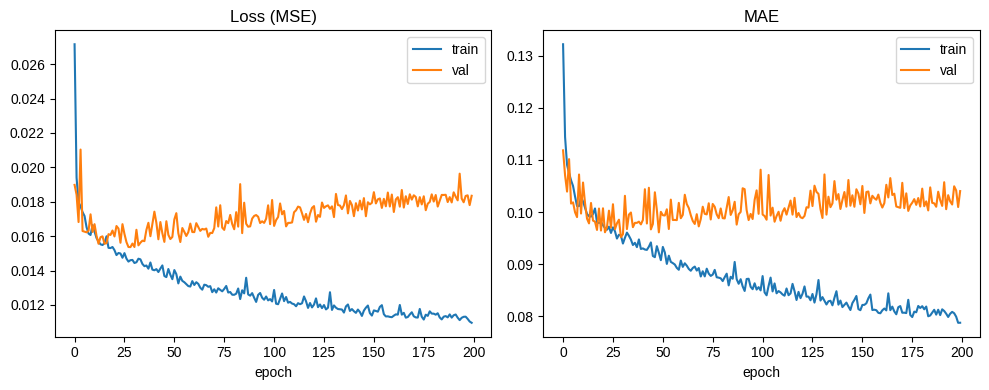

In [98]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss (MSE)'); plt.xlabel('epoch'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.title('MAE'); plt.xlabel('epoch'); plt.legend()
plt.tight_layout(); plt.show()

In [99]:
y_pred_tr = dnn.predict(X_train, verbose=0).ravel()
y_pred_te = dnn.predict(X_test,  verbose=0).ravel()
evaluate('Keras DNN', y_train, y_pred_tr, y_test, y_pred_te,
                    threshold=0.25, n_features=X_train.shape[1])

模型：Keras DNN
-----------------------------------------------------------------
[整體考量]
[Keras DNN (train)] MSE=0.0123 RMSE=0.1107 MAE=0.0841 R²=0.5193 AdjR²=0.5124 RAE=0.6007 RRSE=0.6934
[Keras DNN (test) ] MSE=0.0183 RMSE=0.1354 MAE=0.1039 R²=0.2796 AdjR²=0.2584 RAE=0.7447 RRSE=0.8488
[實務考量]（誤差 < 門檻 → 視為通過）
[Keras DNN (train)] 門檻=25.00% → 通過 4018/5043 筆，正確率 79.67%
[Keras DNN (test) ] 門檻=25.00% → 通過 1805/2484 筆，正確率 72.67%


# svr

In [100]:
from sklearn import svm
from sklearn.preprocessing import StandardScaler

# 簡報建議：SVM 使用前先做特徵標準化
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [101]:
svr = svm.SVR(
    kernel='linear',                # 線性核
    C=1.0,                          # 懲罰係數
    epsilon=0.1)                    # ε 管道寬度（SVR 專屬）
svr.fit(X_train_s, y_train)
y_pred_tr = svr.predict(X_train_s)
y_pred_te = svr.predict(X_test_s)
evaluate('SVR linear', y_train, y_pred_tr, y_test, y_pred_te,
                    threshold=0.25, n_features=X_train_s.shape[1])

模型：SVR linear
-----------------------------------------------------------------
[整體考量]
[SVR linear (train)] MSE=0.0169 RMSE=0.1299 MAE=0.1038 R²=0.3384 AdjR²=0.3289 RAE=0.7417 RRSE=0.8134
[SVR linear (test) ] MSE=0.0174 RMSE=0.1319 MAE=0.1054 R²=0.3164 AdjR²=0.2963 RAE=0.7553 RRSE=0.8268
[實務考量]（誤差 < 門檻 → 視為通過）
[SVR linear (train)] 門檻=25.00% → 通過 3612/5043 筆，正確率 71.62%
[SVR linear (test) ] 門檻=25.00% → 通過 1799/2484 筆，正確率 72.42%


# 鄰近法

In [102]:
from sklearn.neighbors import KNeighborsRegressor

for w in ['uniform', 'distance']:
    knnr = KNeighborsRegressor(
        n_neighbors=5,              # K = 5 個鄰居
        weights=w,                  # 'uniform' 或 'distance'
        metric='minkowski',         # Minkowski 距離
        p=2)                        # p=2 → 歐幾里得
    knnr.fit(X_train_s, y_train)
    y_pred_tr = knnr.predict(X_train_s)
    y_pred_te = knnr.predict(X_test_s)
    evaluate('K-NN (weights=%s)' % w, y_train, y_pred_tr, y_test, y_pred_te,
                        threshold=0.25, n_features=X_train_s.shape[1])

模型：K-NN (weights=uniform)
-----------------------------------------------------------------
[整體考量]
[K-NN (weights=uniform) (train)] MSE=0.0143 RMSE=0.1195 MAE=0.0908 R²=0.4401 AdjR²=0.4321 RAE=0.6490 RRSE=0.7483
[K-NN (weights=uniform) (test) ] MSE=0.0178 RMSE=0.1334 MAE=0.1007 R²=0.3006 AdjR²=0.2800 RAE=0.7217 RRSE=0.8363
[實務考量]（誤差 < 門檻 → 視為通過）
[K-NN (weights=uniform) (train)] 門檻=25.00% → 通過 3765/5043 筆，正確率 74.66%
[K-NN (weights=uniform) (test) ] 門檻=25.00% → 通過 1803/2484 筆，正確率 72.58%
模型：K-NN (weights=distance)
-----------------------------------------------------------------
[整體考量]
[K-NN (weights=distance) (train)] MSE=0.0107 RMSE=0.1034 MAE=0.0699 R²=0.5813 AdjR²=0.5753 RAE=0.4997 RRSE=0.6471
[K-NN (weights=distance) (test) ] MSE=0.0191 RMSE=0.1382 MAE=0.1019 R²=0.2493 AdjR²=0.2272 RAE=0.7301 RRSE=0.8664
[實務考量]（誤差 < 門檻 → 視為通過）
[K-NN (weights=distance) (train)] 門檻=25.00% → 通過 4112/5043 筆，正確率 81.54%
[K-NN (weights=distance) (test) ] 門檻=25.00% → 通過 1786/2484 筆，正確率 71.90%


# 貝式回歸

In [103]:
from sklearn.linear_model import BayesianRidge

bayr = BayesianRidge(
    max_iter=300,                   # 最大迭代次數
    tol=1e-3,                       # 收斂容差
    alpha_1=1e-6,                   # alpha 的先驗超參
    alpha_2=1e-6,
    lambda_1=1e-6,                  # lambda 的先驗超參
    lambda_2=1e-6,
    fit_intercept=True)             # 估計截距
bayr.fit(X_train, y_train)
y_pred_tr = bayr.predict(X_train)
y_pred_te = bayr.predict(X_test)
evaluate('BayesianRidge', y_train, y_pred_tr, y_test, y_pred_te,
                    threshold=0.25, n_features=X_train.shape[1])

模型：BayesianRidge
-----------------------------------------------------------------
[整體考量]
[BayesianRidge (train)] MSE=0.0167 RMSE=0.1294 MAE=0.1039 R²=0.3438 AdjR²=0.3345 RAE=0.7424 RRSE=0.8100
[BayesianRidge (test) ] MSE=0.0171 RMSE=0.1306 MAE=0.1047 R²=0.3293 AdjR²=0.3096 RAE=0.7502 RRSE=0.8189
[實務考量]（誤差 < 門檻 → 視為通過）
[BayesianRidge (train)] 門檻=25.00% → 通過 3598/5043 筆，正確率 71.35%
[BayesianRidge (test) ] 門檻=25.00% → 通過 1790/2484 筆，正確率 72.06%


In [104]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel

# 核函式組合：DotProduct（線性）+ WhiteKernel（雜訊）
kernel = DotProduct() + WhiteKernel()
gpr = GaussianProcessRegressor(
    kernel=kernel,                  # 指定核函式
    random_state=0)                 # 亂數種子
gpr.fit(X_train, y_train)
y_pred_tr = gpr.predict(X_train)
y_pred_te = gpr.predict(X_test)
evaluate('GPR (Dot+White)', y_train, y_pred_tr, y_test, y_pred_te,
                    threshold=0.25, n_features=X_train.shape[1])

KeyboardInterrupt: 

In [105]:
# Load libraries
import pandas as pd
from sklearn.tree import DecisionTreeClassifier  # Import Decision Tree Classifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn import metrics  # Import scikit-learn metrics module for accuracy calculation

In [108]:
def evaluate_reg(model, name, X_train, y_train, X_test, y_test, threshold=0.01):
    # Train metrics
    y_tr_pred = model.predict(X_train)
    tr_mse  = mean_squared_error(y_train, y_tr_pred)
    tr_rmse = np.sqrt(tr_mse)
    tr_mae  = mean_absolute_error(y_train, y_tr_pred)
    tr_r2   = 1 - tr_mse / np.var(y_train)

    # Test metrics
    y_te_pred = model.predict(X_test)
    te_mse  = mean_squared_error(y_test, y_te_pred)
    te_rmse = np.sqrt(te_mse)
    te_mae  = mean_absolute_error(y_test, y_te_pred)
    te_r2   = 1 - te_mse / np.var(y_test)

    # 通過門檻百分比 (誤差 < threshold)
    ytest = y_test.values
    err = np.abs((ytest - y_te_pred) / ytest)
    pass_count = (err < threshold).sum()

    print(f'=== {name} ===')
    print(f"{'':<10}{'Train':>12}{'Test':>12}")
    print(f"{'MSE':<10}{tr_mse:>12.5f}{te_mse:>12.5f}")
    print(f"{'RMSE':<10}{tr_rmse:>12.5f}{te_rmse:>12.5f}")
    print(f"{'MAE':<10}{tr_mae:>12.5f}{te_mae:>12.5f}")
    print(f"{'R^2':<10}{tr_r2:>12.5f}{te_r2:>12.5f}")
    print(f'通過 {threshold*100:.0f}% 誤差門檻: {pass_count}/{len(ytest)}'
          f'  ({pass_count/len(ytest)*100:.1f}%)')
    return te_r2

In [109]:
from xgboost import XGBRegressor

xgbr = XGBRegressor(
    n_estimators       = 100,
    learning_rate      = 0.3,
    max_depth          = 6,
    subsample          = 1.0,
    colsample_bytree   = 1.0,
    gamma              = 0,
    reg_lambda         = 1,
    reg_alpha          = 0,
    min_child_weight   = 1,
    objective          = 'reg:squarederror',
    random_state       = 1000,
    n_jobs             = -1,
)
xgbr.fit(X_train, y_train)
evaluate_reg(xgbr, 'XGBoost Regressor', X_train, y_train, X_test, y_test)

AttributeError: 'numpy.ndarray' object has no attribute 'values'